In [2]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [3]:
df = pd.read_csv("../../dataset/Cleaned_Suicide_Detection_ML.csv")
df.shape

(231988, 4)

In [4]:
X = df["clean_text"]
y = df["labels"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
tfidf = TfidfVectorizer(max_features=7000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [7]:
model = LinearSVC()

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [8]:
y_pred = model.predict(X_test_tfidf)

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94     23078
           1       0.94      0.93      0.94     23320

    accuracy                           0.94     46398
   macro avg       0.94      0.94      0.94     46398
weighted avg       0.94      0.94      0.94     46398



In [10]:
print(accuracy_score(y_test, y_pred))

0.9370878055088582


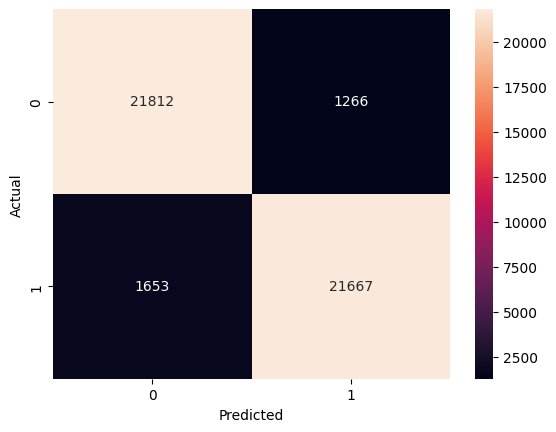

In [11]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
sample = ["i don't want to die"]
sample_tfidf = tfidf.transform(sample)

pred = model.predict(sample_tfidf)
pred


array([1])

In [13]:
joblib.dump(model, "../../models/svm_model.pkl")

['../../models/svm_model.pkl']